**Import the useful packages** 

In [1]:
# Import useful packages
import numpy as np
import xarray as xr
import glob
import matplotlib.pyplot as plt
import os,sys
import pandas as pd
# To avoid problems with tensorflow, add the following lines before importing it
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
from tensorflow import keras
# To avoid problems with nn_functions, add the following lines before importing it 
import sys
sys.path.insert(1, '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt')
#from nn_functions.constants import *
#import nn_functions.diagnostic_functions as diag
#import nn_functions.data_formatting as dfmt
import nn_functions.postprocessing_functions as pp
#from nn_functions.constants import *
# To import various params associated with the experiment exp_name
import define_params 
# For plotting things on the polar stereographic grid with lat and lon coordinates 
import cartopy.crs as ccrs
proj=ccrs.SouthPolarStereo(central_longitude=0.0)
trans=ccrs.PlateCarree()
import time

**Set the parameters for this specific run**

In [2]:
# Load in all the data
def load_test_data_whole_sim(this_collection, verbose = 0, keep_pandas = False):
    fp_apply = path_norm_metrics + this_collection + '_not_yet_normalised.csv'
    df_sel = pd.read_csv(fp_apply)
    print('\033[1m' + 'You have loaded data to apply the nn to:' + '\033[0m')
    print(fp_apply)
    print('You have kept the whole dataset')
    # Convert imported data to xarray
    if keep_pandas == False:
        clean_df = df_sel.to_xarray()
        return clean_df
    else:
        return df_sel

def load_test_data_val(this_collection, verbose = 0, keep_pandas = False):
    fp_apply = path_norm_metrics + this_collection + '_val_data.nc'
    df_sel = xr.open_dataset(fp_apply)
    df_sel = df_sel.sel(norm_method = norm_method).drop('norm_method')
    print('\033[1m' + 'You have loaded data to apply the nn to:' + '\033[0m')
    print(fp_apply)
    print('You have kept the whole dataset')
    if keep_pandas == False:
        return df_sel
    else:
        df_clean = df_sel.to_pandas()
        return df_clean

# Load in a trained neural network model
def load_model_nn(exp_name, this_collection, seed_nb, mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 0, 
                 annual_f = ''):
    fp_model = path_model + 'model_nn_'+ mod_size + '_' +exp_name + '_' + this_collection + '_' + annual_f + \
                                    str(seed_nb).zfill(2) + '_' + TS_opt + '_' + norm_method + '.keras'
    model = keras.models.load_model(fp_model)
    if verbose == 1:
        print('\033[1m' + 'You have loaded a trained neural network:' + '\033[0m')
        print(fp_model)
    return model

# Load in the normalisation metrics 
def load_normalisation_metrics(this_collection, norm_method = 'std', verbose = 0):
    fp_norm_metrics = path_norm_metrics + this_collection + '_metrics_norm.nc'
    norm_metrics_file = xr.open_dataset(fp_norm_metrics)
    if verbose > 0:
        print('\033[1m' + 'You have loaded normalisation metrics:' + '\033[0m')
        print(fp_norm_metrics)
    norm_metrics = norm_metrics_file.sel(norm_method=norm_method).drop('norm_method').to_dataframe()
    return norm_metrics

# Apply one trained NN to the chosen data 
def apply_model(model, norm_metrics, clean_df, exp_name, verbose = 0):
    # First normalise input data 
    val_norm = pp.normalise_vars(clean_df,
                            norm_metrics.loc['mean_vars'],
                            norm_metrics.loc['range_vars'])
    # Import the desired variables, and create a list 
    var_list = define_params.var_list_by_exp_name(exp_name)
    input_vars = list(np.array(var_list)[~(np.array(var_list) == 'melt_m_ice_per_y')])
    # Split into input and reference datasets
    x_val_norm = val_norm[input_vars]
    y_val_norm = val_norm['melt_m_ice_per_y']
    # Apply the model 
    #shape = x_val_norm.to_array().values.shape[1], x_val_norm.to_array().values.shape[0]
    #y_out_norm = model.predict(x_val_norm.to_array().values.reshape(shape),verbose = 0)
    y_out_norm = model.predict(x_val_norm.to_array().values.T,verbose = 0)
    y_out_norm_xr = xr.DataArray(data=y_out_norm.squeeze()).rename({'dim_0': 'index'})
    y_out_norm_xr = y_out_norm_xr.assign_coords({'index': x_val_norm.index})    
    # denormalise the output
    y_out = pp.denormalise_vars(y_out_norm_xr, 
                             norm_metrics['melt_m_ice_per_y'].loc['mean_vars'],
                             norm_metrics['melt_m_ice_per_y'].loc['range_vars'])
    if verbose > 0:
        print('\033[1m' + 'You have applied the neural network to the chosen data:' + '\033[0m')
    return y_out

# Apply all 10 NNs (with the 10 random seeds), and look at the mean 
def apply_nn_save_results(this_collection, exp_name, keep_all_runs = True, \
                         mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 0, annual_only = False, 
                         apply_collection = None, annual_f = ''):
    if apply_collection == None:
        load_collection = this_collection
    else:
        load_collection = apply_collection
    norm_metrics = load_normalisation_metrics(this_collection, verbose = verbose)
    clean_df = load_test_data_whole_sim(load_collection, verbose = verbose)
    if annual_only == True:
        # Get just the annual data 
        clean_pdf = clean_df.to_dataframe()
        df_annual = clean_pdf.groupby(['lat','lon','year'], as_index = False).mean()
        clean_df = df_annual.to_xarray()
    seed_nb_array = np.arange(1,11,1)
    list_melt_seeds = []
    df_ref_pred = pd.DataFrame({'lat': clean_df.lat, 
                                'lon': clean_df.lon,
                                'basin': clean_df.basins_NEMO,
                                'area': clean_df.area, #clean_df.approx_area for OPM026?
                                'year': clean_df.year, 
                                'month': clean_df.month, 
                                'melt_m_ice_per_y': clean_df.melt_m_ice_per_y})
    for i in range(len(seed_nb_array)):
        start_time = time.time()
        list_melt_seeds.append('melt_' + str(i+1).zfill(2))
        if verbose == 2:
            model = load_model_nn(exp_name, this_collection, seed_nb_array[i], \
                              mod_size = mod_size, TS_opt = TS_opt, norm_method = norm_method, \
                              verbose = 1, annual_f = annual_f) 
            df_ref_pred['melt_' + str(i+1).zfill(2)] = apply_model(model, norm_metrics, clean_df, exp_name, verbose = 1)
            end_time = time.time()
            print(seed_nb_array[i], 'out of', len(seed_nb_array), 'processed. Time: {:.0f} s'.format(end_time - start_time), end = '\r')
        else:
            model = load_model_nn(exp_name, this_collection, seed_nb_array[i], \
                              mod_size = mod_size, TS_opt = TS_opt, norm_method = norm_method, \
                              verbose = 0) 
            df_ref_pred['melt_' + str(i+1).zfill(2)] = apply_model(model, norm_metrics, clean_df, exp_name, verbose = 0)
            end_time = time.time()
            print(seed_nb_array[i], 'out of', len(seed_nb_array), 'processed. Time: {:.0f} s'.format(end_time - start_time), end = '\r')
    # Calculate the ensemble mean 
    df_ref_pred['melt_pred_mean'] = np.mean(df_ref_pred[list_melt_seeds], axis = 1).values
    
    # If you want to make the files smaller, you can save the results with just the ensemble mean
    # by setting keep_all_runs to False 
    if keep_all_runs == False:
        df_ref_pred_save = df_ref_pred[list(df_ref_pred.columns.values[~np.isin(list(df_ref_pred.columns.values), list_melt_seeds)])]
        print('Warning, you have not saved the results of each nn, just the ensemble mean')
        sims = 'just_mean'
    else:
        df_ref_pred_save = df_ref_pred
        print('You have saved the results of each nn, and the ensemble mean')
        sims = 'all_sims'
    # Set the filepath and save the output
    if annual_only == False:
        ano = ''
    else:
        ano = '_annual'
    if load_collection == True:
        lc = ''
    else:
        ano = ano + '_special_lc_' + load_collection
    fp_ref_pred = path_model + 'applied_nn' + '_' + mod_size + '_' +exp_name + '_' + this_collection + '_' + annual_f + \
                                        sims + '_' + TS_opt + '_' + norm_method + ano + '.csv'
    df_ref_pred.to_csv(fp_ref_pred, index = False)
    if verbose > 0:
        print('\033[1m' + 'You have saved the results of applying the neural network to the test dataset:' + '\033[0m')
        print(fp_ref_pred)

In [3]:
# Set the filepaths to useful files 
path_model = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/NN_models/'
path_norm_metrics = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/'
models = glob.glob(path_model + '*.keras')
histories = glob.glob(path_model + 'history*.csv')

In [4]:
this_collection_NN = 'OPM026_OPM0263_OPM031_OPM016_OPM018_OPM021_ctrl94_isf94_isfru94'
#this_collection_NN = 'OPM026'
#this_collection_apply = 'OPM0263_whole_dataset'
exp_name = 'slope_front'

In [5]:
mod_size = 'small'
TS_opt = 'extrap'
norm_method = 'std'
annual_only = False, 
annual_f = ''

verbose = 2
norm_metrics = load_normalisation_metrics(this_collection_NN, verbose = verbose)
clean_df = load_test_data_val(this_collection_NN, verbose = verbose)



You have loaded normalisation metrics:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/OPM026_OPM0263_OPM031_OPM016_OPM018_OPM021_ctrl94_isf94_isfru94_metrics_norm.nc
You have loaded data to apply the nn to:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/OPM026_OPM0263_OPM031_OPM016_OPM018_OPM021_ctrl94_isf94_isfru94_val_data.nc
You have kept the whole dataset


In [6]:
df_clean = pp.denormalise_vars(clean_df,
                            norm_metrics.loc['mean_vars'],
                            norm_metrics.loc['range_vars'])
df_ref_pred = pd.DataFrame({'lat': df_clean.lat, 
                            'lon': df_clean.lon,
                            'basin': df_clean.basins_NEMO,
                            'area': df_clean.area, #clean_df.approx_area for OPM026?
                            'year': df_clean.year, 
                            'month': df_clean.month, 
                            'melt_m_ice_per_y': df_clean.melt_m_ice_per_y})

In [7]:
df_ref_pred

,lat,lon,basin,area,year,month,melt_m_ice_per_y
0,-67.103935,58.250000,22.0,1.169811e+08,2034.0,11.0,-7.711237e-04
1,-79.377800,-33.860794,82.0,3.096565e+07,2000.0,2.0,5.334456e-06
2,-84.748474,-162.277400,59.0,1.824226e+07,2022.0,4.0,-1.492573e-04
3,-78.827120,-36.642365,82.0,3.346525e+07,2013.0,NaN,-8.840067e-07
4,-82.200160,-47.377150,84.0,2.301701e+07,1989.0,1.0,1.058371e-06
...,...,...,...,...,...,...,...
4108244,-73.285970,-60.560574,117.0,6.385745e+07,2009.0,2.0,2.673496e-06
4108245,-70.332100,1.004222,9.0,8.612623e+07,2052.0,2.0,-4.412753e-04
4108246,-74.595770,-125.837456,108.0,5.295685e+07,1995.0,6.0,-1.647667e-05
4108247,-81.750810,-158.521060,58.0,2.408753e+07,1988.0,6.0,-3.440990e-07


In [8]:
def apply_model_val(model, norm_metrics, clean_df, exp_name, verbose = 0):
    # First normalise input data 
    val_norm = clean_df
    # Import the desired variables, and create a list 
    var_list = define_params.var_list_by_exp_name(exp_name)
    input_vars = list(np.array(var_list)[~(np.array(var_list) == 'melt_m_ice_per_y')])
    # Split into input and reference datasets
    x_val_norm = val_norm[input_vars]
    y_val_norm = val_norm['melt_m_ice_per_y']
    # Apply the model 
    #shape = x_val_norm.to_array().values.shape[1], x_val_norm.to_array().values.shape[0]
    #y_out_norm = model.predict(x_val_norm.to_array().values.reshape(shape),verbose = 0)
    y_out_norm = model.predict(x_val_norm.to_array().values.T,verbose = 0)
    y_out_norm_xr = xr.DataArray(data=y_out_norm.squeeze()).rename({'dim_0': 'index'})
    y_out_norm_xr = y_out_norm_xr.assign_coords({'index': x_val_norm.index})    
    # denormalise the output
    y_out = pp.denormalise_vars(y_out_norm_xr, 
                             norm_metrics['melt_m_ice_per_y'].loc['mean_vars'],
                             norm_metrics['melt_m_ice_per_y'].loc['range_vars'])
    if verbose > 0:
        print('\033[1m' + 'You have applied the neural network to the chosen data:' + '\033[0m')
    return y_out

In [ ]:
fp_ref_pred = path_model + 'applied_nn_' + this_collection_NN + '_val_data' + '.csv'

In [22]:
apply_model = False
if apply_model == True:
    seed_nb_array = np.arange(1,11,1)
    #seed_nb_array = np.arange(1,3,1)
    list_melt_seeds = []
    for i in range(len(seed_nb_array)):
        start_time = time.time()
        list_melt_seeds.append('melt_' + str(i+1).zfill(2))
        if verbose == 2:
            model = load_model_nn(exp_name, this_collection_NN, seed_nb_array[i], \
                              mod_size = mod_size, TS_opt = TS_opt, norm_method = norm_method, \
                              verbose = 1, annual_f = annual_f) 
            df_ref_pred['melt_' + str(i+1).zfill(2)] = apply_model_val(model, norm_metrics, clean_df, exp_name, verbose = 1)
            end_time = time.time()
            print(seed_nb_array[i], 'out of', len(seed_nb_array), 'processed. Time: {:.0f} s'.format(end_time - start_time), end = '\r')
    # Calculate the ensemble mean 
    df_ref_pred['melt_pred_mean'] = np.mean(df_ref_pred[list_melt_seeds], axis = 1).values

    df_ref_pred.to_csv(fp_ref_pred, index = False)
    if verbose > 0:
        print('\033[1m' + 'You have saved the results of applying the neural network to the test dataset:' + '\033[0m')
        print(fp_ref_pred)

In [12]:
from functions import regression_analysis, twosigfig

In [13]:
df_ref_pred = pd.read_csv(fp_ref_pred)

In [14]:
df_ref_ym = df_ref_pred.groupby(['basin'], as_index = False).mean()
RMSE = np.sqrt(np.mean((df_ref_ym.melt_m_ice_per_y- df_ref_ym.melt_pred_mean)**2))
R2 = regression_analysis(df_ref_ym.melt_m_ice_per_y, df_ref_ym.melt_pred_mean)[2]
print('RMSE:', RMSE*(60*60*24*365.25)/917, 'R2:', R2)

RMSE: 1.3807789987163017 R2: 0.9312734068237464


In [15]:
df_ref_ym = df_ref_pred.groupby(['lat','lon'], as_index = False).mean()
RMSE = np.sqrt(np.mean((df_ref_ym.melt_m_ice_per_y- df_ref_ym.melt_pred_mean)**2))
R2 = regression_analysis(df_ref_ym.melt_m_ice_per_y, df_ref_ym.melt_pred_mean)[2]
print('RMSE:', RMSE*(60*60*24*365.25)/917, 'R2:', R2)

RMSE: 1.1984633465663117 R2: 0.9717676927820474


In [16]:
df_ref_ym = df_ref_pred.groupby(['year','month'], as_index = False).mean()
RMSE = np.sqrt(np.mean((df_ref_ym.melt_m_ice_per_y- df_ref_ym.melt_pred_mean)**2))
R2 = regression_analysis(df_ref_ym.melt_m_ice_per_y, df_ref_ym.melt_pred_mean)[2]
print('RMSE:', RMSE*(60*60*24*365.25)/917, 'R2:', R2)

RMSE: 0.31376491829899705 R2: 0.9945921973403113


In [17]:
RMSE = np.sqrt(np.mean((df_ref_pred.melt_m_ice_per_y- df_ref_pred.melt_pred_mean)**2))
R2 = regression_analysis(df_ref_pred.melt_m_ice_per_y, df_ref_pred.melt_pred_mean)[2]
print('RMSE:', RMSE*(60*60*24*365.25)/917, 'R2:', R2)

RMSE: 3.2899567108707166 R2: 0.9306857152768183


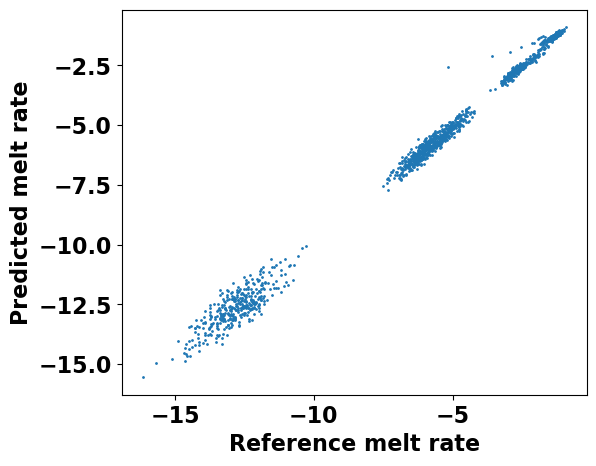

In [18]:
with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
    fig, ax = plt.subplots(1,1, figsize = (6,5))
    ax.scatter(df_ref_ym.melt_m_ice_per_y*(60*60*24*365.25)/917, df_ref_ym.melt_01*(60*60*24*365.25)/917, s = 1)
    ax.set_ylabel('Predicted melt rate')
    ax.set_xlabel('Reference melt rate')
    plt.show()

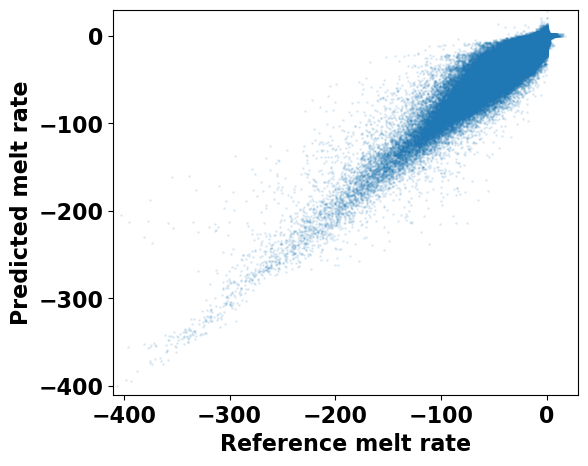

In [19]:
with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
    fig, ax = plt.subplots(1,1, figsize = (6,5))
    ax.scatter(df_ref_pred.melt_m_ice_per_y*(60*60*24*365.25)/917, df_ref_pred.melt_01*(60*60*24*365.25)/917, s = 1, alpha = 0.1)
    ax.set_ylabel('Predicted melt rate')
    ax.set_xlabel('Reference melt rate')
    ax.set_xlim(-410,30)
    ax.set_ylim(-410,30)
    plt.show()